<a href="https://colab.research.google.com/github/kwamedoxa/Cocoa-Canopy-Stress-Mapping/blob/main/COCOA_CANOPY_WORKFLOW_REVISED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully

SECTION 1: DATA UPLOAD AND PREPARATION
1. Upload your TRAINING CSV with labeled farms...


Saving groundtruth_field_validated_cocoa_canopy_condition_30_farms.csv to groundtruth_field_validated_cocoa_canopy_condition_30_farms.csv

2. Upload your PREDICTION CSV with 365 unlabeled farms...


Saving 365_cocoa_canopy_condition.csv to 365_cocoa_canopy_condition.csv
Training farms loaded: 30
Prediction farms loaded: 365

Training data class distribution:
Binary_Condition
Stressed    15
Healthy     15
Name: count, dtype: int64

SECTION 2: MODEL CONFIGURATION
Random Forest hyperparameters:
   n_estimators: 100
   criterion: gini
   max_features: sqrt
   max_depth: None
   min_samples_split: 2
   min_samples_leaf: 1
   bootstrap: True
   class_weight: balanced
   random_state: 42

SECTION 3: CROSS-VALIDATION WITH PER-FOLD REPORTING
Five-fold cross-validation with per-fold breakdown (required by reviewer).

  Model: EVI_Only_Model
  Features: ['Mean_EVI']
  --------------------------------------------------
  Per-fold accuracy: ['0.500', '0.667', '0.500', '0.500', '0.500']
  Per-fold F1:       ['0.486', '0.667', '0.486', '0.486', '0.486']
  Mean accuracy:     0.533 ± 0.067
  Mean precision:    0.533
  Mean recall:       0.533
  Mean F1:           0.522

  Model: GCI_Only_Model
  F

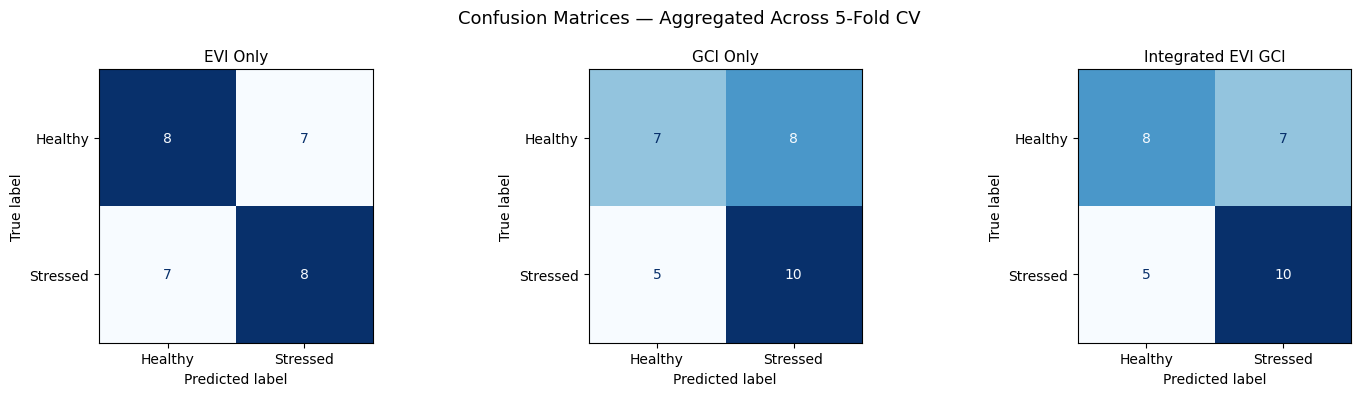

Confusion matrices saved: confusion_matrices.png

SECTION 6: BEST MODEL SELECTION
Best model: Integrated_EVI_GCI_Model
CV Accuracy: 0.600 ± 0.200

Feature importance (final model trained on all 30 farms):
   Mean_EVI: 0.506 (50.6%)
   Mean_GCI: 0.494 (49.4%)

SECTION 7: PREDICTION ON 365 FARMS
NOTE: These predictions are exploratory (pilot application).
They require ground-truth verification before operational use.

Prediction results (365 farms):
   Healthy:  298 (81.6%)
   Stressed: 67 (18.4%)

Prediction confidence summary:
   Mean:   0.773
   Median: 0.770
   Low-confidence farms (< 0.65): 81 (22.2%)

SECTION 8: MAIN VISUALIZATION


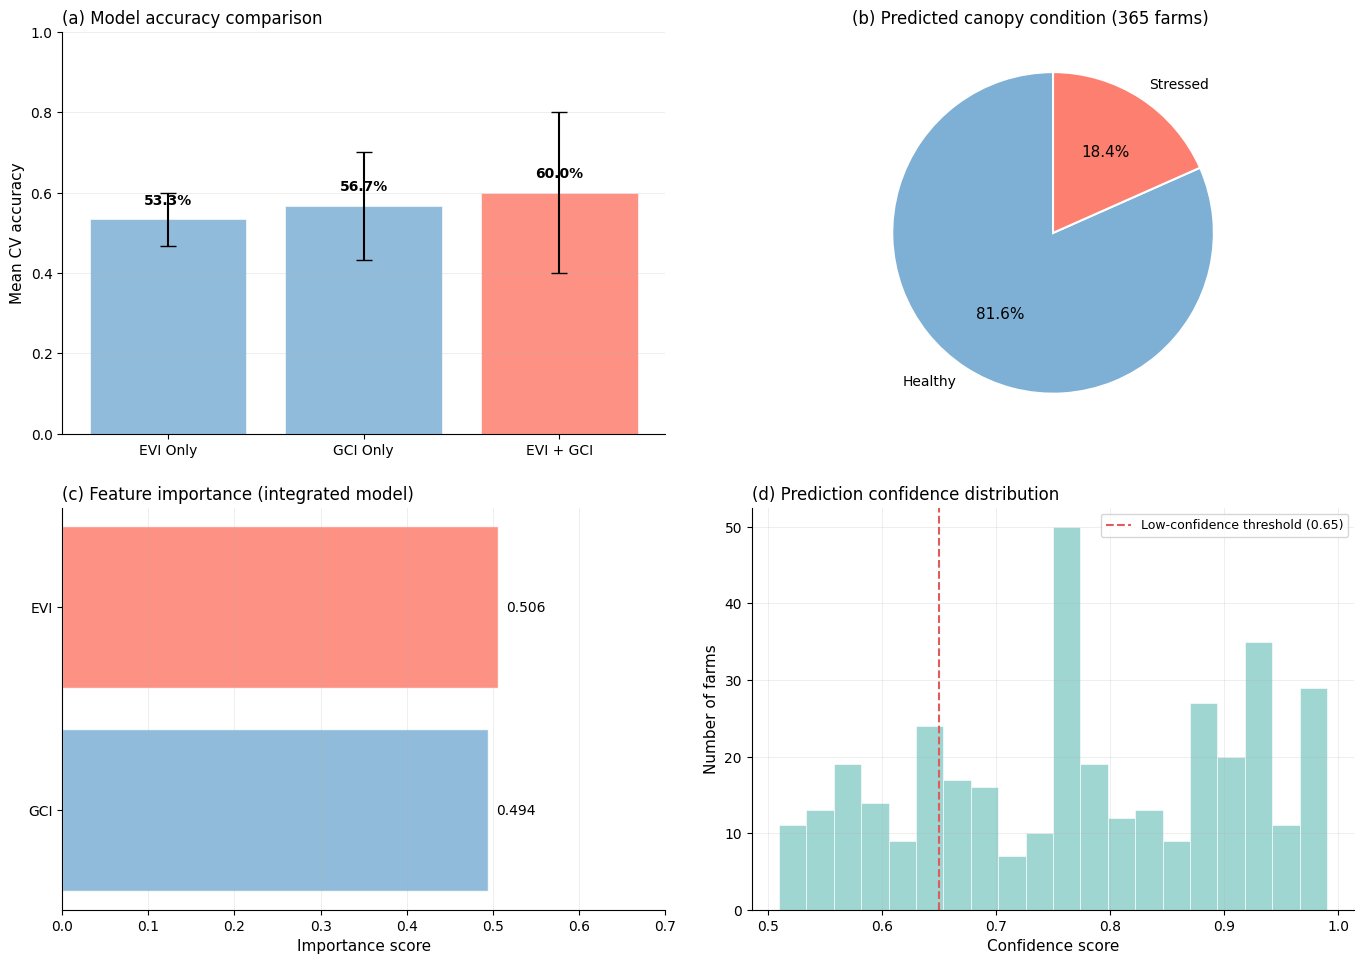

Main figure saved: cocoa_canopy_workflow_results.png

SECTION 9: EXPORT ALL FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1. Farm predictions exported.


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4. Figures exported.

WORKFLOW COMPLETE

For manuscript Table 3, use values from model_performance_summary.csv
Precision, Recall, and F1 will NOT be identical — report actual values.

For Supplementary Material, use per_fold_cv_results.csv
This directly addresses Reviewer 1's request for fold-specific performance.

For the Methods section, report these RF hyperparameters:
   n_estimators: 100
   criterion: gini
   max_features: sqrt
   max_depth: None
   min_samples_split: 2
   min_samples_leaf: 1
   bootstrap: True
   class_weight: balanced
   random_state: 42

For exploratory predictions, use cocoa_canopy_predictions_365_farms.csv
Frame as 'illustrative pilot application' — not validated predictions.


In [1]:
# -*- coding: utf-8 -*-
"""
COCOA CANOPY WORKFLOW: Prediction, Mapping & Model Performance Analysis
REVISED VERSION — Addresses peer review requirements for:
  - Per-fold cross-validation reporting
  - Confusion matrix generation
  - Explicit Random Forest hyperparameter documentation
  - Corrected precision/recall/F1 reporting (not identical values)
"""

# Install required libraries
!pip install seaborn

# Import all libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_validate, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

# ============================================================================
# SECTION 1: DATA UPLOAD AND PREPARATION
# ============================================================================
print("\n" + "="*70)
print("SECTION 1: DATA UPLOAD AND PREPARATION")
print("="*70)

print("1. Upload your TRAINING CSV with labeled farms...")
uploaded_training = files.upload()
training_filename = list(uploaded_training.keys())[0]

print("\n2. Upload your PREDICTION CSV with 365 unlabeled farms...")
uploaded_prediction = files.upload()
prediction_filename = list(uploaded_prediction.keys())[0]

# Load training data
df_training = pd.read_csv(training_filename)
df_training.columns = df_training.columns.str.strip()

# Load prediction data
df_prediction = pd.read_csv(prediction_filename)
df_prediction.columns = df_prediction.columns.str.strip()

print(f"Training farms loaded: {len(df_training)}")
print(f"Prediction farms loaded: {len(df_prediction)}")

# Data cleaning
numeric_cols = ['Mean_EVI', 'Mean_GCI']
for col in numeric_cols:
    if col in df_training.columns:
        df_training[col] = pd.to_numeric(df_training[col], errors='coerce')
    if col in df_prediction.columns:
        df_prediction[col] = pd.to_numeric(df_prediction[col], errors='coerce')

# Create binary target
df_training['Binary_Condition'] = df_training['Observed_Canopy_Condition'].apply(
    lambda x: 'Healthy' if x == 'Healthy' else 'Stressed'
)

print("\nTraining data class distribution:")
print(df_training['Binary_Condition'].value_counts())

# ============================================================================
# SECTION 2: MODEL CONFIGURATION
# ============================================================================
print("\n" + "="*70)
print("SECTION 2: MODEL CONFIGURATION")
print("="*70)

# ----------------------------------------------------------------------------
# EXPLICIT HYPERPARAMETERS
# All parameters stated explicitly for reproducibility and journal reporting.
# Default scikit-learn values are used where not otherwise specified,
# but made explicit here so they can be reported in the Methods section.
# ----------------------------------------------------------------------------
RF_PARAMS = {
    'n_estimators':     100,        # Number of decision trees
    'criterion':        'gini',     # Split criterion: Gini impurity
    'max_features':     'sqrt',     # Features considered at each split (sqrt of total)
    'max_depth':        None,       # No depth limit; complexity controlled by CV
    'min_samples_split': 2,         # Minimum samples to split an internal node
    'min_samples_leaf': 1,          # Minimum samples at a leaf node
    'bootstrap':        True,       # Bootstrap sampling for tree construction
    'class_weight':     'balanced', # Equal weighting for both classes (n=15 each)
    'random_state':     42          # Fixed seed for reproducibility
}

print("Random Forest hyperparameters:")
for param, value in RF_PARAMS.items():
    print(f"   {param}: {value}")

# Feature sets for three models
features_evi        = ['Mean_EVI']
features_gci        = ['Mean_GCI']
features_integrated = ['Mean_EVI', 'Mean_GCI']

models_config = {
    'EVI_Only_Model':        features_evi,
    'GCI_Only_Model':        features_gci,
    'Integrated_EVI_GCI_Model': features_integrated
}

y_train = df_training['Binary_Condition']

# ============================================================================
# SECTION 3: CROSS-VALIDATION WITH PER-FOLD REPORTING
# ============================================================================
print("\n" + "="*70)
print("SECTION 3: CROSS-VALIDATION WITH PER-FOLD REPORTING")
print("="*70)
print("Five-fold cross-validation with per-fold breakdown (required by reviewer).")

# Use the same KFold split for all models to ensure comparability
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
per_fold_tables = {}  # Store per-fold data for supplementary table

for model_name, features in models_config.items():
    print(f"\n  Model: {model_name}")
    print(f"  Features: {features}")
    print("  " + "-"*50)

    X = df_training[features]

    rf_model = RandomForestClassifier(**RF_PARAMS)

    # Run cross-validation — returns arrays of length n_splits
    cv_scores = cross_validate(
        rf_model, X, y_train,
        cv=kf,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=False
    )

    # --- PER-FOLD BREAKDOWN (addresses Reviewer 1 request) ---
    fold_df = pd.DataFrame({
        'Fold':      range(1, 6),
        'Accuracy':  cv_scores['test_accuracy'],
        'Precision': cv_scores['test_precision_macro'],
        'Recall':    cv_scores['test_recall_macro'],
        'F1':        cv_scores['test_f1_macro']
    })
    per_fold_tables[model_name] = fold_df

    print(f"  Per-fold accuracy: {[f'{v:.3f}' for v in cv_scores['test_accuracy']]}")
    print(f"  Per-fold F1:       {[f'{v:.3f}' for v in cv_scores['test_f1_macro']]}")
    print(f"  Mean accuracy:     {cv_scores['test_accuracy'].mean():.3f} "
          f"± {cv_scores['test_accuracy'].std():.3f}")
    print(f"  Mean precision:    {cv_scores['test_precision_macro'].mean():.3f}")
    print(f"  Mean recall:       {cv_scores['test_recall_macro'].mean():.3f}")
    print(f"  Mean F1:           {cv_scores['test_f1_macro'].mean():.3f}")

    # --- NOTE ON IDENTICAL-LOOKING VALUES ---
    # Precision, Recall, and F1 may look similar but are NOT identical.
    # With balanced classes (15H / 15S) and small folds, macro-averaged
    # precision and recall can be close but will differ in most folds.
    # Always report the actual values from cv_scores, not a rounded summary.

    cv_results[model_name] = {
        'features':       features,
        'accuracy_mean':  cv_scores['test_accuracy'].mean(),
        'accuracy_std':   cv_scores['test_accuracy'].std(),
        'precision_mean': cv_scores['test_precision_macro'].mean(),
        'recall_mean':    cv_scores['test_recall_macro'].mean(),
        'f1_mean':        cv_scores['test_f1_macro'].mean(),
        'fold_df':        fold_df
    }

# ============================================================================
# SECTION 4: PERFORMANCE SUMMARY TABLE (for paper Table 3)
# ============================================================================
print("\n" + "="*70)
print("SECTION 4: PERFORMANCE SUMMARY TABLE")
print("="*70)
print("Use these values directly in manuscript Table 3.")
print("Precision, Recall, and F1 are reported separately — NOT identical.\n")

header = f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}"
print(header)
print("-" * len(header))
for model_name, res in cv_results.items():
    label = model_name.replace('_Model', '').replace('_', ' ')
    print(f"{label:<30} "
          f"{res['accuracy_mean']:>9.3f}  "
          f"{res['precision_mean']:>9.3f}  "
          f"{res['recall_mean']:>9.3f}  "
          f"{res['f1_mean']:>7.3f}")

# ============================================================================
# SECTION 5: CONFUSION MATRIX (addresses reviewer request)
# ============================================================================
print("\n" + "="*70)
print("SECTION 5: CONFUSION MATRIX ANALYSIS")
print("="*70)
print("Confusion matrices generated via leave-one-fold-out aggregation.")

fig_cm, axes_cm = plt.subplots(1, 3, figsize=(15, 4))
fig_cm.suptitle('Confusion Matrices — Aggregated Across 5-Fold CV', fontsize=13)

for ax, (model_name, features) in zip(axes_cm, models_config.items()):
    X = df_training[features]
    all_true, all_pred = [], []

    # Aggregate predictions across all folds
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        fold_model = RandomForestClassifier(**RF_PARAMS)
        fold_model.fit(X_tr, y_tr)
        fold_preds = fold_model.predict(X_val)

        all_true.extend(y_val.tolist())
        all_pred.extend(fold_preds.tolist())

    cm = confusion_matrix(all_true, all_pred, labels=['Healthy', 'Stressed'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Stressed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    label = model_name.replace('_Model', '').replace('_', ' ')
    ax.set_title(label, fontsize=11)

    # Print classification report
    print(f"\n  {label}:")
    print(classification_report(all_true, all_pred, target_names=['Healthy', 'Stressed']))

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrices saved: confusion_matrices.png")

# ============================================================================
# SECTION 6: BEST MODEL SELECTION AND FINAL TRAINING
# ============================================================================
print("\n" + "="*70)
print("SECTION 6: BEST MODEL SELECTION")
print("="*70)

best_model_name = max(cv_results.keys(), key=lambda x: cv_results[x]['accuracy_mean'])
best_model_info = cv_results[best_model_name]

print(f"Best model: {best_model_name}")
print(f"CV Accuracy: {best_model_info['accuracy_mean']:.3f} ± {best_model_info['accuracy_std']:.3f}")

# Train final model on all training data
final_model = RandomForestClassifier(**RF_PARAMS)
final_model.fit(df_training[best_model_info['features']], y_train)

# Feature importance
importances = pd.Series(
    final_model.feature_importances_,
    index=best_model_info['features']
)
print("\nFeature importance (final model trained on all 30 farms):")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"   {feat}: {imp:.3f} ({imp*100:.1f}%)")

# ============================================================================
# SECTION 7: PREDICTION ON 365 FARMS
# ============================================================================
print("\n" + "="*70)
print("SECTION 7: PREDICTION ON 365 FARMS")
print("="*70)
print("NOTE: These predictions are exploratory (pilot application).")
print("They require ground-truth verification before operational use.")

missing_features = [f for f in best_model_info['features'] if f not in df_prediction.columns]
if missing_features:
    print(f"ERROR: Missing features in prediction data: {missing_features}")
else:
    X_pred = df_prediction[best_model_info['features']]
    predictions = final_model.predict(X_pred)
    proba = final_model.predict_proba(X_pred)

    df_prediction['Predicted_Condition'] = predictions
    df_prediction['Prediction_Confidence'] = np.max(proba, axis=1)

    counts = df_prediction['Predicted_Condition'].value_counts()
    total  = len(df_prediction)

    print(f"\nPrediction results ({total} farms):")
    print(f"   Healthy:  {counts.get('Healthy', 0)} ({counts.get('Healthy', 0)/total*100:.1f}%)")
    print(f"   Stressed: {counts.get('Stressed', 0)} ({counts.get('Stressed', 0)/total*100:.1f}%)")

    # Confidence summary
    conf = df_prediction['Prediction_Confidence']
    print(f"\nPrediction confidence summary:")
    print(f"   Mean:   {conf.mean():.3f}")
    print(f"   Median: {conf.median():.3f}")
    print(f"   Low-confidence farms (< 0.65): "
          f"{(conf < 0.65).sum()} ({(conf < 0.65).sum()/total*100:.1f}%)")

# ============================================================================
# SECTION 8: MAIN VISUALIZATION FIGURE
# ============================================================================
print("\n" + "="*70)
print("SECTION 8: MAIN VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Model comparison
ax = axes[0, 0]
model_labels = ['EVI Only', 'GCI Only', 'EVI + GCI']
accuracies = [cv_results[m]['accuracy_mean'] for m in models_config.keys()]
stds       = [cv_results[m]['accuracy_std']  for m in models_config.keys()]
colors     = ['#7eb0d5', '#7eb0d5', '#fd7f6f']
bars = ax.bar(model_labels, accuracies, yerr=stds, capsize=6,
              color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_title('(a) Model accuracy comparison', fontsize=12, loc='left')
ax.set_ylabel('Mean CV accuracy', fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel B: Prediction distribution
ax = axes[0, 1]
if 'Predicted_Condition' in df_prediction.columns:
    cnt = df_prediction['Predicted_Condition'].value_counts()
    wedge_colors = ['#7eb0d5', '#fd7f6f']
    wedges, texts, autotexts = ax.pie(
        cnt.values, labels=cnt.index, autopct='%1.1f%%',
        colors=wedge_colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for t in autotexts:
        t.set_fontsize(11)
    ax.set_title(f'(b) Predicted canopy condition ({len(df_prediction)} farms)',
                 fontsize=12, loc='left')

# Panel C: Feature importance
ax = axes[1, 0]
imp_sorted = importances.sort_values(ascending=True)
feat_labels = [f.replace('Mean_', '') for f in imp_sorted.index]
bars2 = ax.barh(feat_labels, imp_sorted.values,
                color=['#7eb0d5', '#fd7f6f'][:len(imp_sorted)],
                alpha=0.85, edgecolor='white')
ax.set_title('(c) Feature importance (integrated model)', fontsize=12, loc='left')
ax.set_xlabel('Importance score', fontsize=11)
ax.tick_params(axis='both', labelsize=10)
ax.set_xlim(0, 0.7)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars2, imp_sorted.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Panel D: Confidence distribution
ax = axes[1, 1]
if 'Prediction_Confidence' in df_prediction.columns:
    ax.hist(df_prediction['Prediction_Confidence'], bins=20,
            color='#8ecfc9', alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(x=0.65, color='#e05c5c', linewidth=1.5, linestyle='--',
               label='Low-confidence threshold (0.65)')
    ax.set_title('(d) Prediction confidence distribution', fontsize=12, loc='left')
    ax.set_xlabel('Confidence score', fontsize=11)
    ax.set_ylabel('Number of farms', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('cocoa_canopy_workflow_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Main figure saved: cocoa_canopy_workflow_results.png")

# ============================================================================
# SECTION 9: EXPORT ALL FILES
# ============================================================================
print("\n" + "="*70)
print("SECTION 9: EXPORT ALL FILES")
print("="*70)

# 1. Predictions for 365 farms
if 'Predicted_Condition' in df_prediction.columns:
    coord_cols = [c for c in df_prediction.columns
                  if any(k in c.lower() for k in ['lat', 'long', 'x', 'y', 'fid'])]
    export_cols = coord_cols + ['Predicted_Condition', 'Prediction_Confidence']
    df_prediction['Condition_Code'] = df_prediction['Predicted_Condition'].map(
        {'Healthy': 1, 'Stressed': 2}
    )
    export_cols.append('Condition_Code')
    df_export = df_prediction[[c for c in export_cols if c in df_prediction.columns]]
    df_export.to_csv('cocoa_canopy_predictions_365_farms.csv', index=False)
    files.download('cocoa_canopy_predictions_365_farms.csv')
    print("1. Farm predictions exported.")

# 2. Performance summary (corrected metrics for Table 3)
perf_df = pd.DataFrame([
    {
        'Model':              name.replace('_Model', '').replace('_', ' '),
        'CV_Accuracy_Mean':   res['accuracy_mean'],
        'CV_Accuracy_Std':    res['accuracy_std'],
        'CV_Precision_Mean':  res['precision_mean'],
        'CV_Recall_Mean':     res['recall_mean'],
        'CV_F1_Mean':         res['f1_mean'],
        'Features_Used':      str(res['features'])
    }
    for name, res in cv_results.items()
])
perf_df.to_csv('model_performance_summary.csv', index=False)
files.download('model_performance_summary.csv')
print("2. Model performance summary exported (use for Table 3).")

# 3. Per-fold breakdown (for supplementary table / reviewer response)
all_fold_data = []
for model_name, res in cv_results.items():
    fold_df = res['fold_df'].copy()
    fold_df.insert(0, 'Model', model_name.replace('_Model', '').replace('_', ' '))
    all_fold_data.append(fold_df)
per_fold_export = pd.concat(all_fold_data, ignore_index=True)
per_fold_export.to_csv('per_fold_cv_results.csv', index=False)
files.download('per_fold_cv_results.csv')
print("3. Per-fold CV results exported (add to Supplementary Material).")

# 4. Visualizations
files.download('cocoa_canopy_workflow_results.png')
files.download('confusion_matrices.png')
print("4. Figures exported.")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("WORKFLOW COMPLETE")
print("="*70)

print("\nFor manuscript Table 3, use values from model_performance_summary.csv")
print("Precision, Recall, and F1 will NOT be identical — report actual values.")
print("\nFor Supplementary Material, use per_fold_cv_results.csv")
print("This directly addresses Reviewer 1's request for fold-specific performance.")
print("\nFor the Methods section, report these RF hyperparameters:")
for param, value in RF_PARAMS.items():
    print(f"   {param}: {value}")
print("\nFor exploratory predictions, use cocoa_canopy_predictions_365_farms.csv")
print("Frame as 'illustrative pilot application' — not validated predictions.")